In [ ]:
from risk_estimation.datasets.risk_feature_extractor import *
from risk_estimation.datasets.frame_dropping import *
from video_embedding.models.video_embedder import VideoEmbedder
from risk_estimation.models.gp_risk_estimator import TwinGPRiskEstimator
from risk_estimation.datasets.risk_dataloader import RiskEstimationDataset
from video_embedding.utils import all_test_names, all_trial_names
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine

/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:

session, embedding_approach = "AE2", "Autoencoder2"
# session, embedding_approach = "AE2_100", "Autoencoder2"
# session, embedding_approach = "AE", "Autoencoder"
# session, embedding_approach = "AE2", "Autoencoder2"
# session, embedding_approach = "AE2_100", "LargeAutoencoder"
from video_embedding.utils import set_session; set_session(session)

# framedrop_policy = OnlyLabelledFramesDroppingPolicyRiskPegPick()
# framedrop_policy = OnlyLabelledFramesDroppingPolicyRiskPegDoor()
# framedrop_policy = OnlyLabelledFramesDroppingPolicyRiskPegPlace()
# framedrop_policy = OnlyLabelledFramesDroppingPolicy()
framedrop_policy = NoFrameDroppingPolicy()

skill_name="peg_pick404"
l=12
features=StampedLatentObservationsRiskLabels()
video_embedder = VideoEmbedder(name=skill_name, latent_dim=l, nn_model=embedding_approach)
video_embedder.load_model()
re = TwinGPRiskEstimator(name=skill_name, xdim=l, learning_rate=0.01, train_patience=6000, train_epoch=6000)  

Loading model: /home/petr/ilesia_ws/src/ILeSiA/video_embedding/saved_models/AE2//peg_pick404_Autoencoder2_12.pt


In [3]:
video_train_names = all_trial_names(skill_name)
video_test_names = all_test_names(skill_name)

dataset_nodrop = RiskEstimationDataset.load_dataset(video_train_names, video_embedder,
    frame_dropping_policy=NoFrameDroppingPolicy, features=features)

train_dataset, train_imgset, test_dataset, test_imgset = RiskEstimationDataset.extended_load(
    video_train_names, video_test_names, video_embedder, framedrop_policy, features)

# optional, not aligned with other dataloaders
re.dataloader_test_for_plot = DataLoader(test_dataset, batch_size=video_embedder.batch_size, shuffle=True)
re.dataloader_nodrop_for_plot = DataLoader(dataset_nodrop, batch_size=video_embedder.batch_size, shuffle=True)


/home/petr/miniconda3/envs/ilesia/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


In [ ]:

re.training_loop(DataLoader(train_dataset, batch_size=video_embedder.batch_size), early_stop=True)


In [4]:
train_dataset.X.shape

torch.Size([3096, 13])

In [7]:

# benchmark_eval_save("Train_dataset", skill_name, train_dataset, train_imgset, video_embedder, re)
# benchmark_eval_save("Test_dataset", skill_name, test_dataset, test_imgset, video_embedder, re)


In [ ]:
def load_exec(name):
    dataset = RiskEstimationDataset.load_dataset([name], video_embedder, 40, framedrop_policy, features)
    X = dataset.X[:,:].cpu()
    Y = dataset.Y[:,:].cpu().squeeze()
    return X, Y

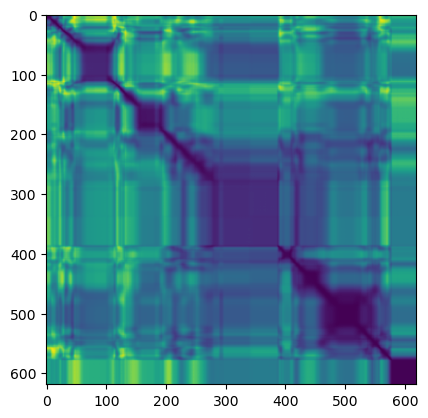

In [58]:
X1, Y1 = load_exec("peg_pick404_test_0")
X2, Y2 = load_exec("peg_pick404_test_2")
t1X = X1[:,:-1].cpu()
t2X = X2[:,:-1].cpu()
t1Y = Y1[:-1].cpu()
t2Y = Y2[:-1].cpu()
ood = np.zeros((t1X.shape[0], t2X.shape[0]))
for n,i in enumerate(t1X):
    for m,j in enumerate(t2X):
        ood[n,m] = cosine(i, j)
plt.imshow(ood)

In [43]:
import plotly.express as px
from sklearn.decomposition import PCA

In [59]:
pca = PCA(n_components=2)
X, y = load_exec("peg_pick404_test_5")
X_pca = pca.fit_transform(X[:,:-1])
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=X[:,-1])
fig.show()